# Level 2 - Task 2: Cuisine Combination Analysis

## Objective

The objective of this task is to analyze restaurants offering multiple cuisines and identify the most common cuisine combinations.

### This task includes:

- Finding the most common cuisine combinations.
- Analyzing whether cuisine combinations receive higher ratings.
- Visualizing the top cuisine combinations.

### Libraries Used

- Pandas
- Matplotlib
- Seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load Dataset
df = pd.read_csv("../Dataset.csv")

## Step 1: Check Missing Values

Check whether the Cuisine column contains missing values.

In [5]:
df["Cuisines"].isnull().sum()

9

## Step 2: Remove Missing Cuisine Records

Rows with missing cuisine information are removed before analysis.

In [8]:
cuisine_df = df.dropna(subset=["Cuisines"])

print("Total Restaurants:", len(cuisine_df))

Total Restaurants: 9542


## Step 3: Find the Most Common Cuisine Combinations

Count the frequency of each cuisine combination.

In [11]:
cuisine_counts = cuisine_df["Cuisines"].value_counts()

cuisine_counts.head(10)

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

## Step 4: Create Summary Table

Display the top 10 cuisine combinations.

In [14]:
summary = pd.DataFrame({
    "Cuisine Combination": cuisine_counts.head(10).index,
    "Restaurant Count": cuisine_counts.head(10).values
})

summary

,Cuisine Combination,Restaurant Count
0,North Indian,936
1,"North Indian, Chinese",511
2,Chinese,354
3,Fast Food,354
4,"North Indian, Mughlai",334
5,Cafe,299
6,Bakery,218
7,"North Indian, Mughlai, Chinese",197
8,"Bakery, Desserts",170
9,Street Food,149


## Step 5: Visualize Top Cuisine Combinations

A horizontal bar chart is used to visualize the top cuisine combinations.

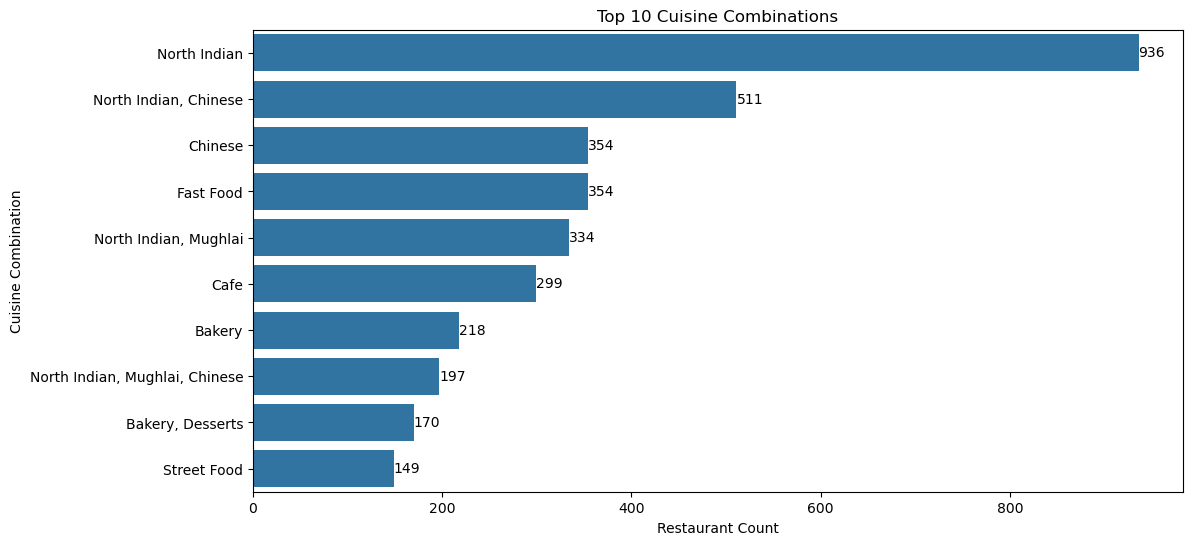

In [17]:
os.makedirs("../images", exist_ok=True)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=summary,
    x="Restaurant Count",
    y="Cuisine Combination"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Cuisine Combinations")
plt.xlabel("Restaurant Count")
plt.ylabel("Cuisine Combination")

plt.savefig(
    "../images/top_cuisine_combinations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 6: Average Rating of Top Cuisine Combinations

Calculate the average rating for the most common cuisine combinations.

In [22]:
avg_rating = (
    cuisine_df.groupby("Cuisines")["Aggregate rating"]
    .mean()
    .sort_values(ascending=False)
)

avg_rating.head(10)

Cuisines
Italian, Deli               4.9
Hawaiian, Seafood           4.9
American, Sandwich, Tea     4.9
Continental, Indian         4.9
European, Asian, Indian     4.9
European, Contemporary      4.9
European, German            4.9
BBQ, Breakfast, Southern    4.9
American, Coffee and Tea    4.9
Sunda, Indonesian           4.9
Name: Aggregate rating, dtype: float64

## Step 7: Compare Ratings of the Most Popular Cuisine Combinations

This analysis focuses on the top 10 cuisine combinations by restaurant count and compares their average ratings.

In [25]:
top10 = cuisine_counts.head(10).index

rating_summary = (
    cuisine_df[cuisine_df["Cuisines"].isin(top10)]
    .groupby("Cuisines")["Aggregate rating"]
    .mean()
    .sort_values(ascending=False)
)

rating_summary

Cuisines
Cafe                              2.890970
North Indian, Mughlai             2.888623
North Indian, Mughlai, Chinese    2.568528
North Indian, Chinese             2.421722
Bakery, Desserts                  2.317647
Street Food                       2.161745
Fast Food                         2.118362
Chinese                           2.042090
Bakery                            1.924312
North Indian                      1.672329
Name: Aggregate rating, dtype: float64

## Step 8: Visualize Average Ratings

The following chart compares the average ratings of the most popular cuisine combinations.

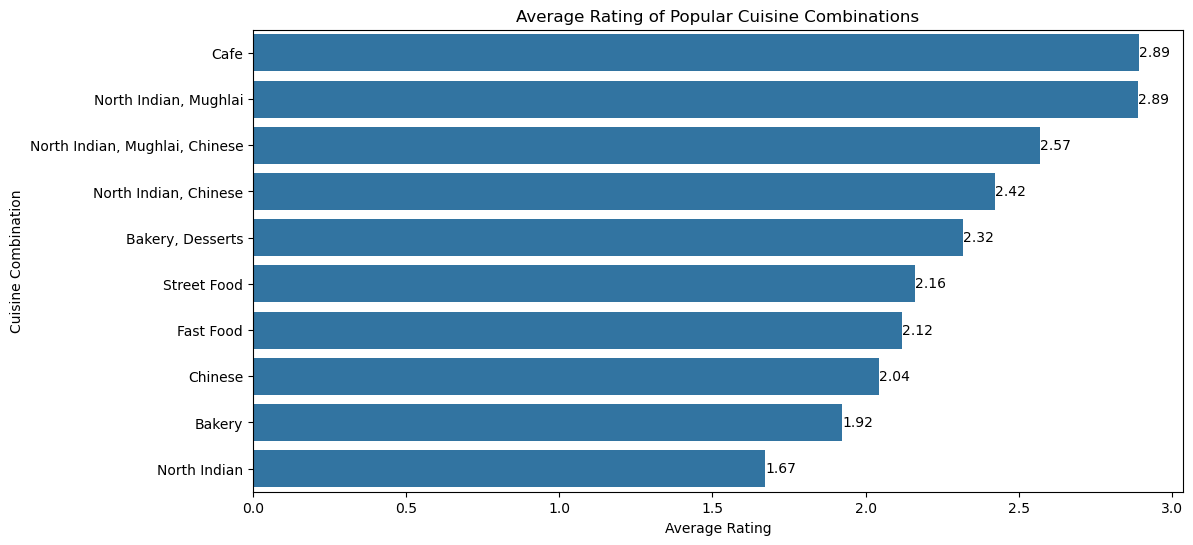

In [28]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=rating_summary.values,
    y=rating_summary.index
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Average Rating of Popular Cuisine Combinations")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine Combination")

plt.savefig(
    "../images/cuisine_combination_ratings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Business Insight

- Restaurants offering multiple cuisines can attract a wider range of customers.
- Certain cuisine combinations are significantly more popular than others.
- Comparing average ratings helps identify combinations that customers appreciate the most.
- Restaurant owners can use these insights when planning menus.

# Conclusion

## Key Findings

- The most popular cuisine combinations were identified.
- The top 10 combinations were visualized.
- Average ratings were compared for popular cuisine combinations.
- The analysis highlights combinations that balance popularity and customer satisfaction.

This information is valuable for menu planning and business strategy.